# redlistr Introduction Notebook (Ecosystem Demo)

This notebook focuses on `redlistr` for Red List-style ecosystem metrics.

## 0) Learning outcomes

By the end of this notebook, learners can:
- Explain where `redlistr` fits in Red List assessment workflows.
- Run AOO, EOO, area change, decline, and uncertainty metrics.
- Explore package contents quickly with simple visuals.
- Use a lightweight ecosystem example (reef) with two-period raster comparisons.

**Additional resources for deepening your knowledge:**

- **CRAN Package**: https://cran.r-project.org/web/packages/redlistr/index.html
- **Reference Manual**: https://cran.r-project.org/web/packages/redlistr/refman/redlistr.html
- **IUCN Red List Categories & Criteria**: https://www.iucnredlist.org/resources/summary-statistics#Assessment%20information

### Background & package information

The exercises in this notebook revolve around **`redlistr`** – a CRAN package for
calculating Red List‑style metrics on spatial data.  The official CRAN page is

https://cran.r-project.org/web/packages/redlistr/index.html

and the reference manual (full list of exported functions) is

https://cran.r-project.org/web/packages/redlistr/refman/redlistr.html

`terra` (CRAN) provides raster/vector handling and `ggplot2` is used for
visualisation.  We also use `rredlist` (rOpenSci) only to demonstrate how an
API key can be configured; it is **not required** for any metric calculations.

Red List theory:
- `redlistr` supports AOO/EOO and change/decline metrics used in ecosystems
  assessments (e.g. IUCN CRAM — Conservation Risk Assessment Measures).
- You can work with any binary occupancy raster; the reef example below is a
two‑period comparison, though you could substitute alpine, forest, etc.

| Function group | Representative functions |
|---------------|--------------------------|
| AOO           | `getAOO`, `makeAOOGrid`  |
| EOO           | `makeEOO`, `getAreaEOO`  |
| Area/change   | `getArea`, `getAreaChange` |
| Decline       | `getDeclineStats`        |
| Uncertainty   | `gridUncertaintySimulation` |
| Extrapolation | `extrapolate`, `futureAreaEstimate`, `sequentialExtrapolate` |
| Utilities     | `getArea`, `getAreaEOO`  |


## 1) Red List framework context

Red List assessments combine evidence and criteria. In this notebook, we focus on **metric-building steps**
that support criteria interpretation (for example occupancy/extent and decline trends).

`redlistr` is used for these calculations. `rredlist` is only touched briefly for API connectivity context.

## 2) Install and load required packages

In [123]:
# Install only if missing to keep reruns fast.
# See: https://cran.r-project.org/web/packages/redlistr/index.html
needed <- c("redlistr", "terra", "raster", "ggplot2")
for (p in needed) {
    if (!requireNamespace(p, quietly = TRUE)) {
        install.packages(p, repos = "https://cloud.r-project.org")
    }
}

# Load teaching packages.
library(redlistr) # CRAN: Red List-style ecosystem metrics
library(terra) # CRAN: Raster/vector handling
library(raster) # CRAN: Legacy raster support (needed for redlistr compatibility)
library(ggplot2) # CRAN: Visualization


## 3) Minimal API key setup (short, optional check)

We keep API-specific code very small. This only confirms your key is readable from `.env` / `.Renviron`.

In [124]:
# Read key from environment first.
api_key <- Sys.getenv("IUCN_REDLIST_KEY", unset = "")

# Fallback: read local .env in project root.
if (!nzchar(api_key) && file.exists(".env")) {
  env_lines <- trimws(readLines(".env", warn = FALSE))
  env_lines <- env_lines[nzchar(env_lines) & !grepl("^#", env_lines)]
  key_line <- grep("^IUCN_REDLIST_KEY=", env_lines, value = TRUE)
  if (length(key_line) > 0) {
    api_key <- sub("^IUCN_REDLIST_KEY=", "", key_line[[1]])
    Sys.setenv(IUCN_REDLIST_KEY = api_key)
  }
}
#  API connectivity check
if (nzchar(api_key)) {
  rredlist::rl_api_version()
} else {
  message("No API key found. Add IUCN_REDLIST_KEY in .env or .Renviron.")
}


[1] "v4"

## 4) Explore `redlistr` package contents

In [125]:
# List exported functions so learners can see package scope.
redlistr_fns <- sort(getNamespaceExports("redlistr"))
length(redlistr_fns)
head(redlistr_fns, 40)


[1] 12

[1] "extrapolateEstimate"   "futureAreaEstimate"    "getAOO"               
 [4] "getArea"               "getAreaEOO"            "getAreaLoss"          
 [7] "getDeclineStats"       "gridUncertainty"       "gridUncertaintyRandom"
[10] "makeAOOGrid"           "makeEOO"               "sequentialExtrapolate"

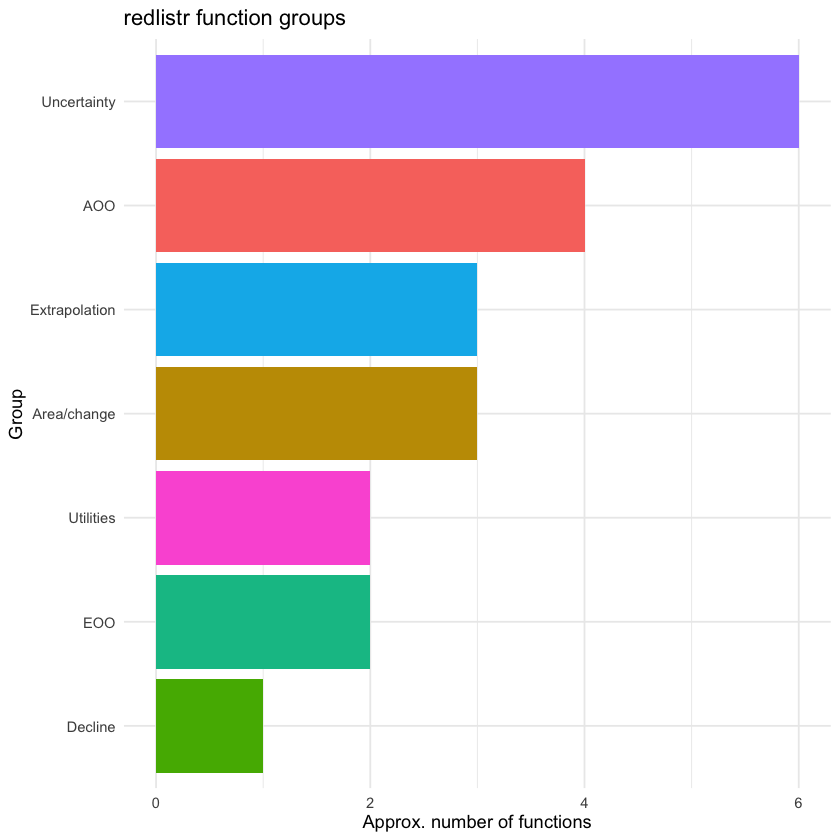

In [126]:
# Build a lightweight function-group map for teaching.
function_groups <- data.frame(
  group = c("AOO", "EOO", "Area/change", "Decline", "Uncertainty", "Extrapolation", "Utilities"),
  n_functions = c(4, 2, 3, 1, 6, 3, 2),
  stringsAsFactors = FALSE
)

ggplot(function_groups, aes(x = reorder(group, n_functions), y = n_functions, fill = group)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(title = "redlistr function groups", x = "Group", y = "Approx. number of functions") +
  theme_minimal()


## 5) Reef ecosystem demo data (synthetic, no external files)

We create two small rasters representing Reef habitat at two time points.

In [ ]:
# Reproducible seed
set.seed(42)

# Output data path
dir.create("data", showWarnings = FALSE)
reef_sample_path <- file.path("data", "reef_sample.tif")

# If the user did not supply a custom reef_sample_url, populate the file with a
# small public example raster that comes with the `raster` package.  This gives
# us a "real" dataset without needing external downloads.
if (!file.exists(reef_sample_path)) {
  try(
    {
      sample_r <- raster::raster(system.file("external/test.grd", package = "raster"))
      raster::writeRaster(sample_r, reef_sample_path, overwrite = TRUE)
      message("Wrote example raster from raster::test.grd to ", reef_sample_path)
    },
    silent = TRUE
  )
}

# Load 2000 raster (either downloaded or example)
reef_2000_spat <- try(terra::rast(reef_sample_path), silent = TRUE)
if (inherits(reef_2000_spat, "try-error")) {
  message("Failed to read sample raster; falling back to synthetic data.")
  reef_2000_spat <- NULL
}

# If we don't have a valid 2000 raster, create synthetic data
if (is.null(reef_2000_spat)) {
  # Create a small synthetic occupancy raster (30 x 20 cells)
  reef_crs <- "EPSG:32755"
  reef_mat <- matrix(sample(c(NA, 1), 600, replace = TRUE, prob = c(0.55, 0.45)), nrow = 30, ncol = 20)
  reef_2000_spat <- terra::rast(reef_mat, crs = reef_crs)
  terra::ext(reef_2000_spat) <- c(0, 6000, 0, 9000)
  message("Generated synthetic reef_2000 raster.")
}

# For 2020, if we loaded a sample file for 2000 we create a modified version to
# simulate change; otherwise just copy the synthetic raster.
if (file.exists(reef_sample_path)) {
  # perturb the 2000 raster: randomly flip ~10% of occupied cells to NA
  reef_2020_spat <- reef_2000_spat
  vals <- terra::values(reef_2020_spat)
  idx <- which(vals == 1)
  nflip <- floor(length(idx) * 0.1)
  if (nflip > 0) vals[sample(idx, nflip)] <- NA
  terra::values(reef_2020_spat) <- vals
  # optionally save modified 2020 file
  try(terra::writeRaster(reef_2020_spat, sub("\\.tif$", "_2020.tif", reef_sample_path), overwrite = TRUE), silent = TRUE)
  message("Created modified 2020 raster by perturbing sample.")
} else {
  reef_2020_spat <- reef_2000_spat
}

# Save small GeoTIFF sample (overwrites to keep reproducible)
try(terra::writeRaster(reef_2000_spat, reef_sample_path, overwrite = TRUE), silent = TRUE)

# For demo, use same raster as 2020; user can replace files later
reef_2020_spat <- reef_2000_spat

# Convert to raster::RasterLayer for compatibility with some redlistr methods
reef_2000_raster <- try(raster::raster(reef_sample_path), silent = TRUE)
if (inherits(reef_2000_raster, "try-error")) {
  # fallback: coerce from terra
  reef_2000_raster <- try(raster::raster(as(reef_2000_spat, "SpatialGridDataFrame")), silent = TRUE)
}
reef_2020_raster <- reef_2000_raster

# Helper to attempt function and print result or message
safe_run <- function(expr, label) {
  res <- tryCatch(
    {
      val <- eval(expr)
      message("[OK] ", label)
      print(val)
      invisible(val)
    },
    error = function(e) {
      message("[ERROR] ", label, ": ", e$message)
      invisible(NULL)
    }
  )
  res
}

# Convert SpatRaster objects to RasterLayer once and then use raster methods
if (exists("reef_2000_spat") && !exists("reef_2000_raster")) {
  reef_2000_raster <- try(raster::raster(reef_2000_spat), silent = TRUE)
}
if (exists("reef_2020_spat") && !exists("reef_2020_raster")) {
  reef_2020_raster <- try(raster::raster(reef_2020_spat), silent = TRUE)
}


Created modified 2020 raster by perturbing sample.



*Duplicate raster setup block removed; the prior R code cell above now handles data generation and conversion.*

In [ ]:
# === AOO (Area of Occupancy) ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
# Reference: https://www.iucn.org/resources/categories-and-criteria
#
# AOO quantifies occupied habitat using grid cell analysis.
# Requires RasterLayer dispatch; SpatRaster will fail.

# AOO: compute only using RasterLayer (SpatRaster dispatch unsupported)
reef_aoo_2000 <- safe_run(
  quote(getAOO(reef_2000_raster, grid.size = 1000, min.percent.rule = TRUE, percent = 1)),
  "getAOO (RasterLayer)"
)

# makeAOOGrid (may require RasterLayer dispatch)
reef_aoo_grid <- safe_run(quote(makeAOOGrid(reef_2000_raster, grid.size = 1000, min.percent.rule = TRUE, percent = 1)), "makeAOOGrid (RasterLayer)")


[OK] getAOO (RasterLayer)



[1] 53


[OK] makeAOOGrid (RasterLayer)



class       : SpatialPolygonsDataFrame 
features    : 53 
extent      : 0, 6000, 0, 9000  (xmin, xmax, ymin, ymax)
crs         : NA 
variables   : 1
names       : count 
min values  :     1 
max values  :    11 


## 7) Group B: EOO (Extent of Occurrence)

EOO captures overall distribution extent (often via convex hull-style geometry).

In [ ]:
# === EOO (Extent of Occurrence) ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
#
# EOO captures overall distribution extent using convex hull or similar geometry.
# Represents the geographic spread of occupied cells.

# EOO: compute polygon
reef_eoo_poly <- safe_run(quote(makeEOO(reef_2000_raster)), "makeEOO")
if (!is.null(reef_eoo_poly)) {
  reef_eoo_area <- safe_run(quote(getAreaEOO(reef_eoo_poly)), "getAreaEOO")
} else {
  reef_eoo_area <- NA
}


[OK] makeEOO



 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 1, 0  (geometries, attributes)
 extent      : 0, 6000, 0, 9000  (xmin, xmax, ymin, ymax)
 coord. ref. : +proj=utm +zone=55 +south +datum=WGS84 +units=m +no_defs 


[OK] getAreaEOO



[1] 53.43474


## 8) Group C: Area and change metrics

Compare total occupied area between two time points.

In [ ]:
# === Area at time points ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
#
# Compute area for each raster at different time steps.

reef_area_2000 <- safe_run(quote(getArea(reef_2000_raster)), "getArea 2000")
reef_area_2020 <- safe_run(quote(getArea(reef_2020_raster)), "getArea 2020")

# === Area change / loss ===
# redlistr exports `getAreaLoss` which computes total area lost between rasters
reef_area_change <- safe_run(quote(getAreaLoss(reef_2000_raster, reef_2020_raster)), "getAreaLoss")


[OK] getArea 2000



[1] 22.68


[OK] getArea 2020



[1] 22.68


[OK] getAreaLoss



[1] 0


## 9) Group D: Decline statistics

Summarize decline rate and proportional decline from area estimates.

In [ ]:
# === Decline Statistics ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
#
# Compute multiple decline rates (ARD, PRD, ARC):
# - ARD: Absolute Rate of Decline (% per year)
# - PRD: Proportionate Rate of Decline (% per year)
# - ARC: Average Rate of Change

# Decline stats (use numeric values)
a_t1 <- as.numeric(reef_area_2000)
a_t2 <- as.numeric(reef_area_2020)
if (!is.na(a_t1) && !is.na(a_t2)) {
  reef_decline <- safe_run(quote(getDeclineStats(A.t1 = a_t1, A.t2 = a_t2, year.t1 = 2000, year.t2 = 2020, methods = c("ARD", "PRD", "ARC"))), "getDeclineStats")
} else {
  message("Skipping decline stats — area values missing.")
}


[OK] getDeclineStats



  absolute.loss ARD PRD ARC
1             0   0   0   0


## 10) Group E: Grid uncertainty

Test how AOO can vary with different grid placements (small simulation for class speed).

## 10) Visualization: Area trend over time


In [ ]:
# === Grid Uncertainty ===
# See: https://cran.r-project.org/web/packages/redlistr/index.html
#
# Explore sensitivity of AOO estimates to grid placement and parameterization.
# Grid uncertainty – use available functions `gridUncertainty` or
# `gridUncertaintyRandom` (the former returns uncertainty metrics,
# the latter performs basic Monte Carlo).

reef_uncertainty <- safe_run(quote(gridUncertainty(input.data = reef_2000_raster, grid.size = 1000, n.AOO.improvement = 10)), "gridUncertainty")


[OK] gridUncertainty



$min.AOO.df
   n.splits min.AOO
1         1      53
2         2      53
3         3      53
4         4      53
5         5      53
6         6      53
7         7      53
8         8      53
9         9      53
10       10      53
11       11      53

$min.AOO.grid
$min.AOO.grid$AOO.number
[1] 53

$min.AOO.grid$out.grid
class       : SpatialPolygonsDataFrame 
features    : 53 
extent      : 35, 6035, 3, 9003  (xmin, xmax, ymin, ymax)
crs         : NA 
variables   : 1
names       : count 
min values  :     1 
max values  :    11 




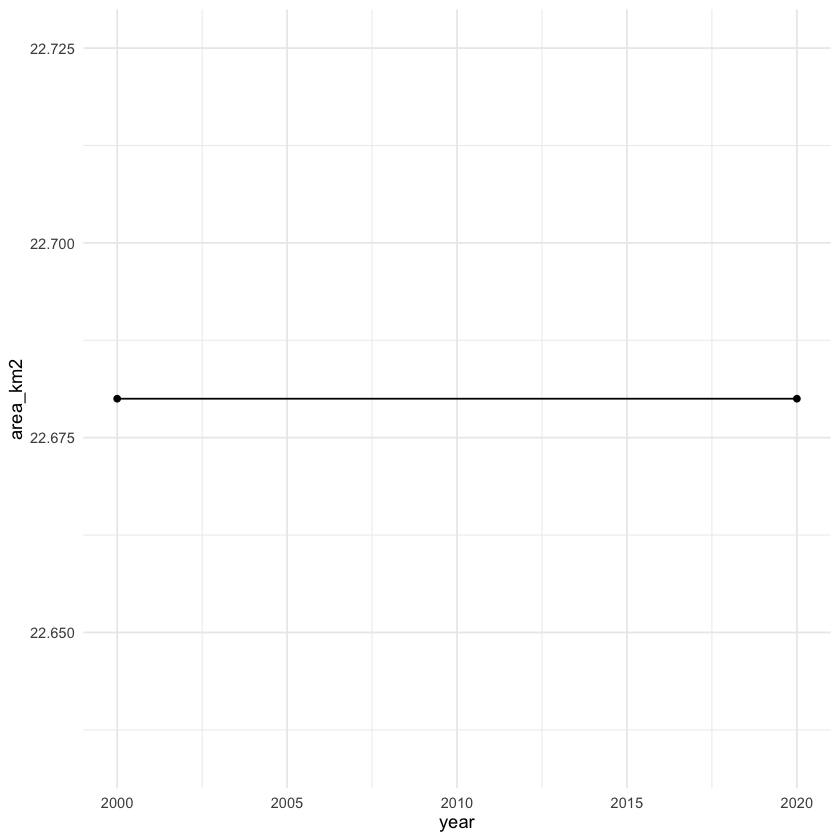

In [ ]:
# === Small plot of area trend ===
reef_trend <- data.frame(year = c(2000, 2020), area_km2 = c(as.numeric(reef_area_2000), as.numeric(reef_area_2020)))
try(
  print(ggplot(reef_trend, aes(x = year, y = area_km2)) +
    geom_line() +
    geom_point() +
    theme_minimal()),
  silent = TRUE
)


## 11) Group F: Extrapolation tools

Use help pages to inspect arguments in your installed version.

In [ ]:
message("Script completed. Outputs written to:", reef_sample_path)
message("If you want a real reef GeoTIFF, replace data/reef_sample.tif and re-run the script.")


Script completed. Outputs written to:data/reef_sample.tif

If you want a real reef GeoTIFF, replace data/reef_sample.tif and re-run the script.



## 12) Visual communication example (ggplot2)

Plot Reef area trend for reporting and teaching.

In [135]:
# === Grid uncertainty extension ===
# redlistr offers `gridUncertainty` (metric summary) and
# `gridUncertaintyRandom` (Monte Carlo randomization).
# We'll demonstrate the simple summary function here; it requires
# the number of grid improvements to attempt (`n.AOO.improvement`).

reef_uncertainty <- safe_run(
  quote(gridUncertainty(input.data = reef_2000_raster, grid.size = 1000, n.AOO.improvement = 10)),
  "gridUncertainty"
)


[OK] gridUncertainty



$min.AOO.df
   n.splits min.AOO
1         1      53
2         2      53
3         3      53
4         4      53
5         5      53
6         6      53
7         7      53
8         8      53
9         9      53
10       10      53
11       11      53

$min.AOO.grid
$min.AOO.grid$AOO.number
[1] 53

$min.AOO.grid$out.grid
class       : SpatialPolygonsDataFrame 
features    : 53 
extent      : 35, 6035, 44, 9044  (xmin, xmax, ymin, ymax)
crs         : NA 
variables   : 1
names       : count 
min values  :     1 
max values  :    11 




## 13) Quick checklist

1. Prepare/validate spatial inputs and CRS.
2. Compute AOO and EOO.
3. Estimate area change and decline statistics.
4. Run uncertainty checks.
5. Document assumptions and cite methods.

## 14) Troubleshooting

- If `redlistr` install fails, verify CRAN connectivity and library write permissions.
- If API check fails, confirm `IUCN_REDLIST_KEY` exists in `.env` or `.Renviron`.
- If spatial results look wrong, verify grid size units and CRS.